In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(757)
n_cases = 500

hampton_schools = [
    'Hampton High School', 'Kecoughtan High School', 'Phoebus High School',
    'Bethel High School', 'Bridgeport Academy', 'Lindsay Middle School',
    'Eaton Middle School', 'Syms Middle School', 'Jones Magnolia Middle'
]

sped_schema = {
    'Case_ID': [f'HAMP-SPED-{10000+i}' for i in range(n_cases)],
    'School_Campus_Name': np.random.choice(hampton_schools, n_cases),
    'Days_Since_Parental_Consent': np.random.randint(15, 90, n_cases),
    'Evaluation_Type': np.random.choice(['Speech-Language', 'Occupational Therapy', 'Psycho-Educational'], n_cases),
    'Current_Case_Manager_Load': np.random.randint(15, 45, n_cases),
    'Parent_Communication_Log_Count': np.random.randint(2, 16, n_cases)
}

df_hampton = pd.DataFrame(sped_schema)
print("Hampton City public schema generated successfully.")
df_hampton.head(3)


Hampton City public schema generated successfully.


,Case_ID,School_Campus_Name,Days_Since_Parental_Consent,Evaluation_Type,Current_Case_Manager_Load,Parent_Communication_Log_Count
0,HAMP-SPED-10000,Phoebus High School,34,Psycho-Educational,36,15
1,HAMP-SPED-10001,Eaton Middle School,48,Speech-Language,32,10
2,HAMP-SPED-10002,Eaton Middle School,74,Speech-Language,27,15


In [5]:
df_hampton['Days_Over_Mandate'] = df_hampton['Days_Since_Parental_Consent'].apply(lambda x: max(0, x - 60))

df_hampton['Legal_Risk_Score'] = (
    (df_hampton['Days_Over_Mandate'] * 2.5) +
    (df_hampton['Current_Case_Manager_Load'] * 0.9) -
    (df_hampton['Parent_Communication_Log_Count'] * 0.6)
)

max_risk = df_hampton['Legal_Risk_Score'].max()
df_hampton['Legal_Risk_Score'] = ((df_hampton['Legal_Risk_Score'] / max_risk) * 100).round(1)
df_hampton['Litigation_Exposure_USD'] = df_hampton['Days_Over_Mandate'].apply(lambda x: 7500 if x > 0 else 0)

print("Compliance indexing engineered successfully.")
df_hampton[['Case_ID', 'School_Campus_Name', 'Legal_Risk_Score', 'Litigation_Exposure_USD']].head(3)


Compliance indexing engineered successfully.


,Case_ID,School_Campus_Name,Legal_Risk_Score,Litigation_Exposure_USD
0,HAMP-SPED-10000,Phoebus High School,22.5,0
1,HAMP-SPED-10001,Eaton Middle School,21.9,0
2,HAMP-SPED-10002,Eaton Middle School,48.3,7500


In [6]:
hampton_summary = df_hampton.groupby('School_Campus_Name').agg(
    Average_Case_Load=('Current_Case_Manager_Load', 'mean'),
    Average_Campus_Risk_Score=('Legal_Risk_Score', 'mean'),
    Total_Litigation_Exposure=('Litigation_Exposure_USD', 'sum'),
    Total_Active_Cases=('Case_ID', 'count')
).reset_index()

X_cluster = hampton_summary[['Average_Campus_Risk_Score', 'Total_Litigation_Exposure']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=757, n_init=10)
hampton_summary['Risk_Tier_Cluster'] = kmeans.fit_predict(X_scaled)

critical_cluster_id = hampton_summary.groupby('Risk_Tier_Cluster')['Average_Campus_Risk_Score'].mean().idxmax()
hampton_summary['Strategic_Action_Plan'] = hampton_summary['Risk_Tier_Cluster'].apply(
    lambda x: 'CRITICAL RISK: DEPLOY EMERGENCY STAFF REALLOCATION' if x == critical_cluster_id else 'ROUTINE MONITORING: STATUS COMPLIANT'
)

print("Clustering engine compiled.")
hampton_summary.sort_values(by='Total_Litigation_Exposure', ascending=False)


Clustering engine compiled.


,School_Campus_Name,Average_Case_Load,Average_Campus_Risk_Score,Total_Litigation_Exposure,Total_Active_Cases,Risk_Tier_Cluster,Strategic_Action_Plan
0,Bethel High School,29.706897,36.003448,195000,58,0,CRITICAL RISK: DEPLOY EMERGENCY STAFF REALLOCA...
8,Syms Middle School,30.678571,35.671429,180000,56,0,CRITICAL RISK: DEPLOY EMERGENCY STAFF REALLOCA...
1,Bridgeport Academy,30.218182,35.170909,165000,55,0,CRITICAL RISK: DEPLOY EMERGENCY STAFF REALLOCA...
3,Hampton High School,32.652174,38.760870,157500,46,0,CRITICAL RISK: DEPLOY EMERGENCY STAFF REALLOCA...
4,Jones Magnolia Middle,31.030769,32.752308,150000,65,2,ROUTINE MONITORING: STATUS COMPLIANT
2,Eaton Middle School,30.446429,29.069643,127500,56,2,ROUTINE MONITORING: STATUS COMPLIANT
7,Phoebus High School,29.245283,31.005660,127500,53,2,ROUTINE MONITORING: STATUS COMPLIANT
5,Kecoughtan High School,28.746032,28.952381,97500,63,1,ROUTINE MONITORING: STATUS COMPLIANT
6,Lindsay Middle School,29.687500,27.333333,75000,48,1,ROUTINE MONITORING: STATUS COMPLIANT


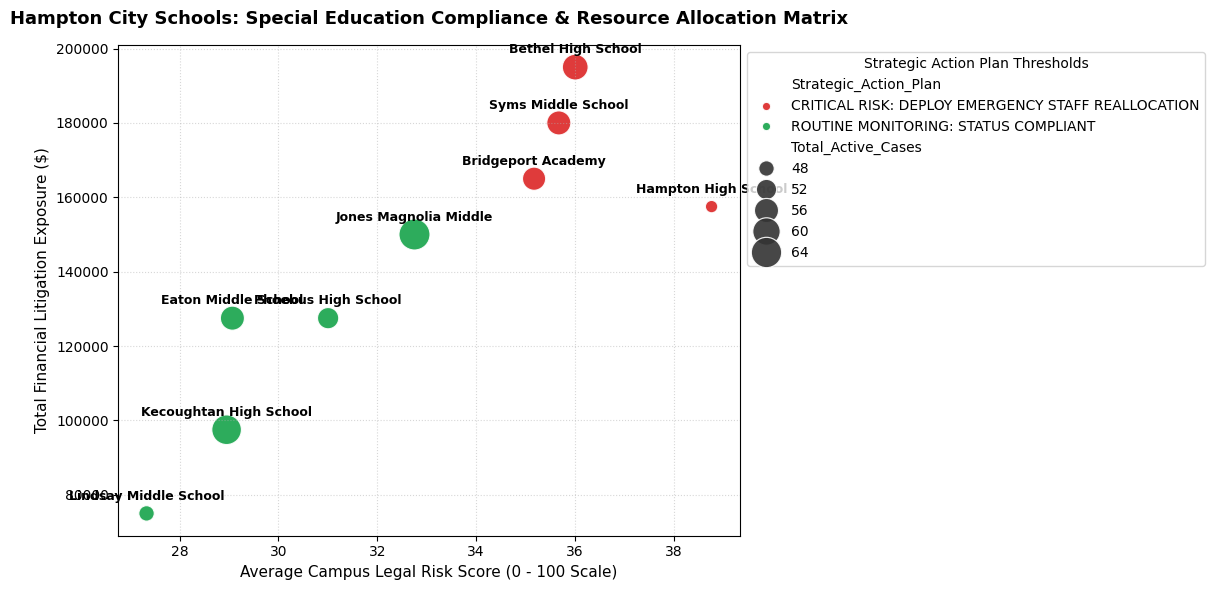

In [7]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='Average_Campus_Risk_Score',
    y='Total_Litigation_Exposure',
    hue='Strategic_Action_Plan',
    size='Total_Active_Cases',
    sizes=(80, 500),
    palette={'CRITICAL RISK: DEPLOY EMERGENCY STAFF REALLOCATION': '#DC2626', 'ROUTINE MONITORING: STATUS COMPLIANT': '#16A34A'},
    data=hampton_summary,
    alpha=0.9
)

for i, txt in enumerate(hampton_summary['School_Campus_Name']):
    plt.annotate(txt, (hampton_summary['Average_Campus_Risk_Score'].iat[i], hampton_summary['Total_Litigation_Exposure'].iat[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, weight='bold')

plt.title('Hampton City Schools: Special Education Compliance & Resource Allocation Matrix', fontsize=13, weight='bold', pad=15)
plt.xlabel('Average Campus Legal Risk Score (0 - 100 Scale)', fontsize=11)
plt.ylabel('Total Financial Litigation Exposure ($)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Strategic Action Plan Thresholds', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
